# resnet on mnist

In [1]:
!pip install tensorflow -q

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test)=mnist.load_data()

#resnet needs rgb
x_train=tf.image.grayscale_to_rgb(tf.expand_dims(x_train,-1))
x_test=tf.image.grayscale_to_rgb(tf.expand_dims(x_test,-1))

#resize to 32x32
x_train=tf.image.resize(x_train,(32,32))
x_test=tf.image.resize(x_test,(32,32))
print(x_train.shape)

(60000, 32, 32, 3)


In [3]:
#normalize 

x_train=x_train/255.0
x_test=x_test/255.0

In [4]:
#load pretrained model & freeze layers, compile

from tensorflow.keras.applications import ResNet50
base=ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))

#freeze for transfer learning
for layer in base.layers:
    layer.trainable=False

#fine tuning -> add custom layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model=Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [5]:
#train model

history=model.fit(x_train, y_train, epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 196s 99ms/step - accuracy: 0.8208 - loss: 0.5678 - val_accuracy: 0.8973 - val_loss: 0.3208
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 177s 94ms/step - accuracy: 0.8962 - loss: 0.3240 - val_accuracy: 0.9016 - val_loss: 0.2968
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 175s 93ms/step - accuracy: 0.9080 - loss: 0.2835 - val_accuracy: 0.9034 - val_loss: 0.2864
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 171s 91ms/step - accuracy: 0.9177 - loss: 0.2578 - val_accuracy: 0.9298 - val_loss: 0.2190
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 170s 91ms/step - accuracy: 0.9237 - loss: 0.2383 - val_accuracy: 0.9340 - val_loss: 0.1976


313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step
[7 2 1 0 4 1 4 8 5 9]


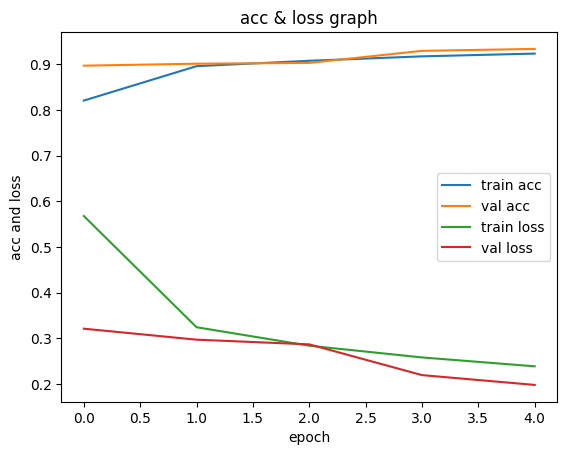

In [6]:
#predc

pred=model.predict(x_test)
pred_classes=pred.argmax(axis=1)
print(pred_classes[:10])

#acc loss graph

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train acc','val acc', 'train loss', 'val loss'])
plt.title("acc & loss graph")
plt.xlabel("epoch")
plt.ylabel("acc and loss")
plt.show()